Imports + Setup

In [1]:
import sys
from pathlib import Path
import importlib

# Path from notebooks/ → project root
project_root = Path("..").resolve()
src_path = project_root / "src"

sys.path.append(str(project_root))
sys.path.append(str(src_path))

print("Added to PYTHONPATH:", project_root, src_path)


Added to PYTHONPATH: /home/rraricha/RadarScenes-ml-project /home/rraricha/RadarScenes-ml-project/src


Load Libaries + Scripts

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Custom loaders
from src.loaders.load_radar import load_radar_h5
from src.loaders.load_sequences import load_scenes_and_sensors
from src.loaders.load_camera import load_any_camera_image, load_camera_image, get_camera_image_path
from src.loaders.load_dataset import (
    list_sequence_ids,
    load_radar_for_sequence,
    load_camera_for_sequence
)


Set Dataset

In [3]:
DATASET_ROOT = Path("/home/rraricha/Datasets/RadarScenes/RadarScenes/data")
print(DATASET_ROOT, DATASET_ROOT.exists())

/home/rraricha/Datasets/RadarScenes/RadarScenes/data True


In [4]:
seq_ids = list_sequence_ids(DATASET_ROOT)
print(f"Total sequences: {len(seq_ids)}")
seq_ids[:10]

Total sequences: 158


['sequence_1',
 'sequence_10',
 'sequence_100',
 'sequence_101',
 'sequence_102',
 'sequence_103',
 'sequence_104',
 'sequence_105',
 'sequence_106',
 'sequence_107']

In [5]:
scenes, sensors = load_scenes_and_sensors(DATASET_ROOT)
print("Number of scenes:", len(scenes["sequences"]))
print("Sensor calibration keys:", sensors.keys())

Number of scenes: 158
Sensor calibration keys: dict_keys(['radar_1', 'radar_2', 'radar_3', 'radar_4'])


Radar Sequence 1

In [6]:
sample_seq = seq_ids[0]
df_radar = load_radar_for_sequence(DATASET_ROOT, sample_seq)
df_radar.head()

,sensor_id,range_sc,azimuth_sc,rcs,vr,vr_compensated,label_id
0,1,2.566963,-0.124031,-28.300673,0.009330,-0.417386,11
1,1,2.096815,0.849328,-26.863953,-8.023678,0.043853,11
2,1,3.338323,1.106456,-26.564907,-9.334642,-0.005208,11
3,2,8.882484,1.156905,0.101503,-7.361293,0.244834,11
4,2,9.479269,1.090472,-3.724234,-7.834501,0.193050,11


Each row is one radar return (a single reflection point), with columns such as:

- range_sc: distance from radar

- azimuth_sc: angle from vehicle forward axis

- rcs: radar cross-section (reflectivity)

- vr / vr_compensated: Doppler velocity

- label_id: object category (if annotated)

Radar Data Description:

In [7]:
df_radar.describe()

,sensor_id,range_sc,azimuth_sc,rcs,vr,vr_compensated,label_id
count,555979.000000,555979.000000,555979.000000,555979.000000,555979.000000,555979.000000,555979.000000
mean,2.749768,29.187574,0.071310,-5.930026,-3.460920,0.084041,10.646023
std,1.054459,21.568937,0.470582,11.153293,5.020902,2.614162,1.910987
min,1.000000,0.839994,-1.221722,-30.599468,-99.184128,-99.187424,0.000000
25%,2.000000,12.657080,-0.266586,-14.075493,-7.456121,-0.043319,11.000000
50%,3.000000,22.787115,0.074540,-7.148669,-2.799739,0.000180,11.000000
75%,4.000000,40.807922,0.408544,1.187045,0.000699,0.057655,11.000000
max,4.000000,99.748718,1.221718,51.125832,93.865532,102.622726,11.000000


In [8]:
df_radar["x"] = df_radar["range_sc"] * np.cos(df_radar["azimuth_sc"])
df_radar["y"] = df_radar["range_sc"] * np.sin(df_radar["azimuth_sc"])
#polar to cartesian coordinates

Scatterplot of Radar Point Cloud

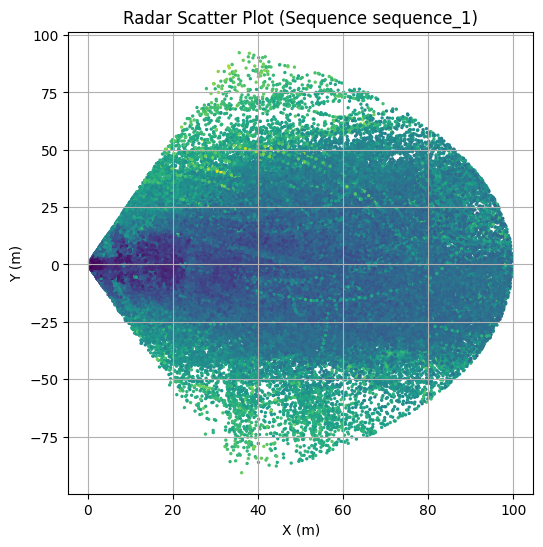

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(df_radar["x"], df_radar["y"], s=2, c=df_radar["rcs"])
plt.title(f"Radar Scatter Plot (Sequence {sample_seq})")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.show()

This scatter plot shows all the radar points detected in one sequence of the RadarScenes dataset. Each dot represents a radar reflection, plotted in X–Y space around the car, where the car sits at the origin. By coloring the points using their reflectivity (RCS), we can see which objects reflect more strongly—usually cars, signs, and metal surfaces. This plot helps us visually confirm that the radar data loads correctly, the coordinate conversion works, and the point cloud has the expected shape and sensor coverage. It also gives us an immediate understanding of what the radar “sees” in the environment before moving on to modeling or projection steps.

Distance + RCS Histograms

In [10]:
df_radar["distance"] = np.sqrt(df_radar["x"]**2 + df_radar["y"]**2)

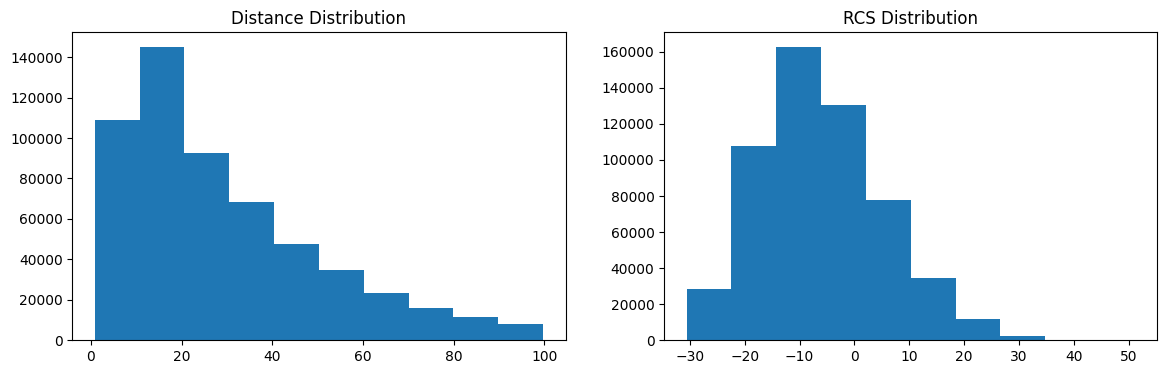

In [11]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.hist(df_radar["distance"])
plt.title("Distance Distribution")

plt.subplot(1,2,2)
plt.hist(df_radar["rcs"])
plt.title("RCS Distribution")

plt.show()


Distance Distribution:
This histogram shows how far most radar detections are from the vehicle. We can see that the majority of points occur at short distances (around 10–25 meters), and the number of detections decreases as distance increases. This is expected because radar is most sensitive to nearby objects and returns fewer reflections from far away. Plotting this helps us understand the effective sensing range of the dataset and check whether distance values look realistic.

RCS Distribution: This plot shows the distribution of RCS (Radar Cross Section), which measures how strongly objects reflect radar signals. Most reflections fall between –20 dB and 10 dB, with fewer strong reflections above that range. This tells us that most objects in the environment are small or non-metallic, while only a few produce strong radar returns. We plot this to confirm that signal strength values are reasonable and to understand how much useful information the radar provides for detection tasks.

Label Distribution

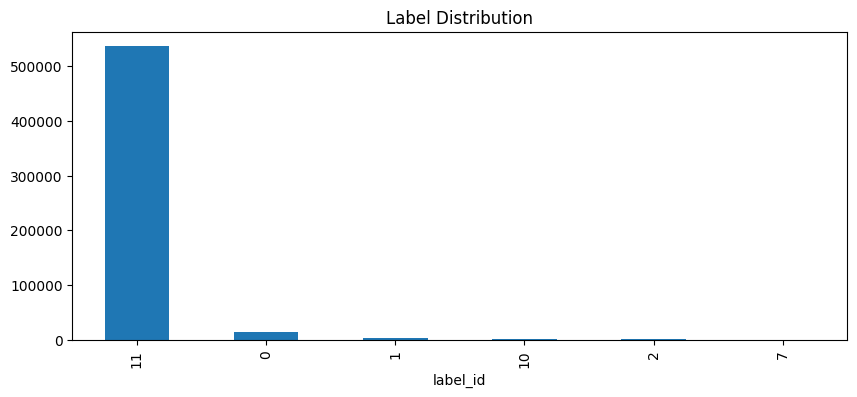

In [12]:
if "label_id" in df_radar.columns:
    df_radar["label_id"].value_counts().plot(kind="bar", figsize=(10,4))
    plt.title("Label Distribution")
    plt.show()
else:
    print("label_id not found in radar file.")


Label Distribution: This bar chart shows how many radar points belong to each object label in the dataset. We can see that one label (ID 11) dominates the dataset with a very large number of points, while the other labels appear only in small amounts. This tells us that the dataset is highly imbalanced. Plotting this is important because label imbalance affects training—models can become biased toward the most common class if we don’t handle it properly (e.g., with weighting, sampling, or careful evaluation). This plot lets us understand what kinds of objects radar sees most often and helps guide how we prepare the data for later modeling steps.

Polar View (Range vs. Azimuth)

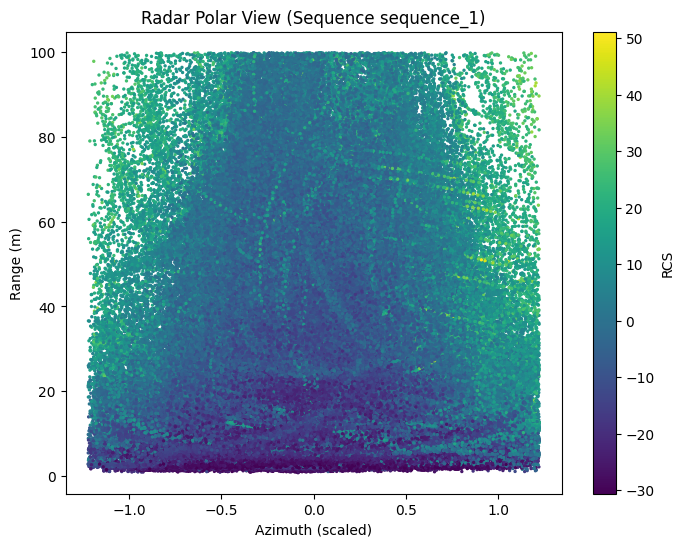

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(df_radar["azimuth_sc"], df_radar["range_sc"], 
            s=2, c=df_radar["rcs"])
plt.title(f"Radar Polar View (Sequence {sample_seq})")
plt.xlabel("Azimuth (scaled)")
plt.ylabel("Range (m)")
plt.colorbar(label="RCS")
plt.show()

This plot shows how far radar points are from the sensor (range) and at what horizontal angle they appear (azimuth). Each dot is one radar return, and the colors represent the strength of the signal (RCS). This view is important because radar data is naturally captured in polar form, so plotting it this way lets us see whether the sensor is working correctly, how the points spread out in front of the vehicle, and whether there are any patterns, blind spots, or noise. This helps confirm that the radar’s angular coverage and range values look realistic before we convert anything into Cartesian coordinates or use the data for machine learning.

Radar Heatmap

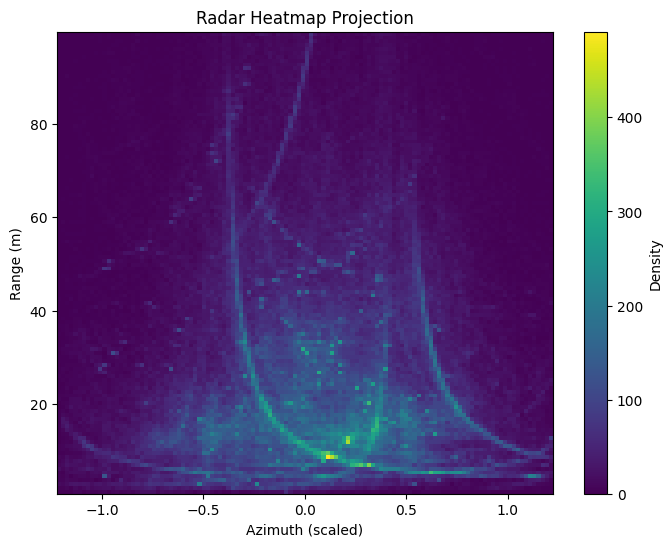

In [14]:
plt.figure(figsize=(8,6))
plt.hist2d(df_radar["azimuth_sc"], df_radar["range_sc"], bins=120, cmap="viridis")
plt.title("Radar Heatmap Projection")
plt.xlabel("Azimuth (scaled)")
plt.ylabel("Range (m)")
plt.colorbar(label="Density")
plt.show()

This heatmap shows where radar detections occur most often across all measured angles (azimuth) and distances (range). Instead of plotting each point individually, the heatmap counts how many radar returns fall into each small grid cell, creating a density map.

Brighter colors (yellow/green) mean many detections in that area, while darker colors (purple/blue) show fewer detections. This reveals large-scale structure that scatter plots sometimes hide — for example, you can see strong vertical “bands” caused by objects that consistently appear at certain angles, and horizontal clusters near the short range indicating lots of returns close to the vehicle.

This plot because it helps you quickly identify patterns, clutter, sensor biases, and common detection zones. It also tells you whether the radar data is balanced across angles and distances or if certain regions dominate, which affects downstream tasks like detection, tracking, or machine learning.

Feature Engineering:

| Feature      | Meaning                              | Why It’s Useful                                            |
| ------------ | ------------------------------------ | ---------------------------------------------------------- |
| `x`, `y`     | Radar points in car coordinate frame | Converts polar → Cartesian for ML models                   |
| `distance`   | Straight-line distance               | Distance is one of the strongest predictors in radar tasks |
| `angle_deg`  | Human-friendly azimuth               | Useful for interpretability + angle-based analysis         |
| `speed_abs`  | Absolute Doppler (velocity)          | Helps detect moving objects                                |
| `power_norm` | RCS normalized 0–1                   | ML models perform better with normalized inputs            |
| Cleaned data | Removed noise                        | Avoids misleading outliers                                 |


In [15]:
from pathlib import Path
from src.feature_engineering import engineer_features, save_parquet
from src.loaders.load_dataset import load_radar_for_sequence

seq_id = seq_ids[0]

df_raw = load_radar_for_sequence(DATASET_ROOT, seq_id)
df_eng = engineer_features(df_raw)

df_eng.head()


,sensor_id,range_sc,azimuth_sc,rcs,vr,vr_compensated,label_id,x,y,distance,angle_deg,speed_abs,power_norm
0,1,2.566963,-0.124031,-28.300673,0.009330,-0.417386,11,2.547244,-0.317566,2.566963,-7.106432,0.009330,0.028128
1,1,2.096815,0.849328,-26.863953,-8.023678,0.043853,11,1.384921,1.574365,2.096815,48.662884,8.023678,0.045708
2,1,3.338323,1.106456,-26.564907,-9.334642,-0.005208,11,1.495011,2.984853,3.338323,63.395271,9.334642,0.049367
3,2,8.882484,1.156905,0.101503,-7.361293,0.244834,11,3.572311,8.132473,8.882484,66.285797,7.361293,0.375661
4,2,9.479269,1.090472,-3.724234,-7.834501,0.193050,11,4.380054,8.406645,9.479270,62.479454,7.834501,0.328848


Feature Correlation Matrix

This helps you see:

-strong correlations (distance ↔ range_sc)

-weak/no correlations (power_norm ↔ angle_deg)

-redundant features

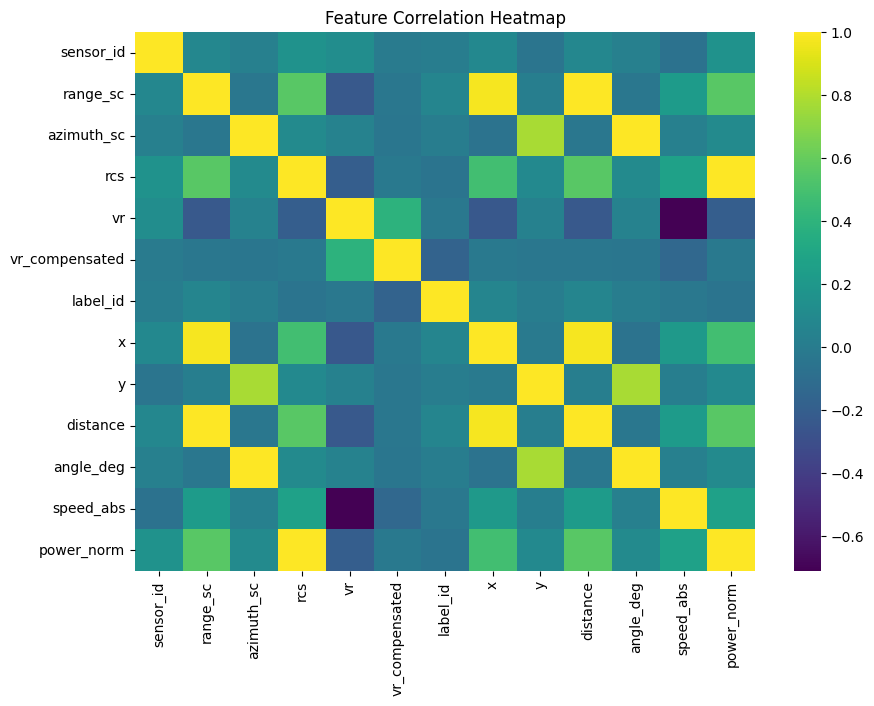

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sns.heatmap(df_eng.corr(), annot=False, cmap="viridis")
plt.title("Feature Correlation Heatmap")
plt.show()


The correlation heatmap shows that the engineered features behave exactly as expected: distance and range_sc are almost identical (since distance is derived from range), and the x/y coordinates correlate cleanly with azimuth_sc, confirming the geometric transformation is correct. Speed_abs strongly tracks vr because it’s just the absolute velocity, and power_norm aligns tightly with RCS since it’s a normalized version of the same signal. Meanwhile, label_id shows almost no correlation with any raw feature, which is ideal—it means the dataset isn’t trivially separable and the ML task is meaningful. Overall, there are no suspicious or unintended correlations, so your feature engineering pipeline looks clean and trustworthy.

PCA to visualize feature space

This shows:

-how radar points cluster

-whether velocity separates moving vs stationary

-if normalization helped

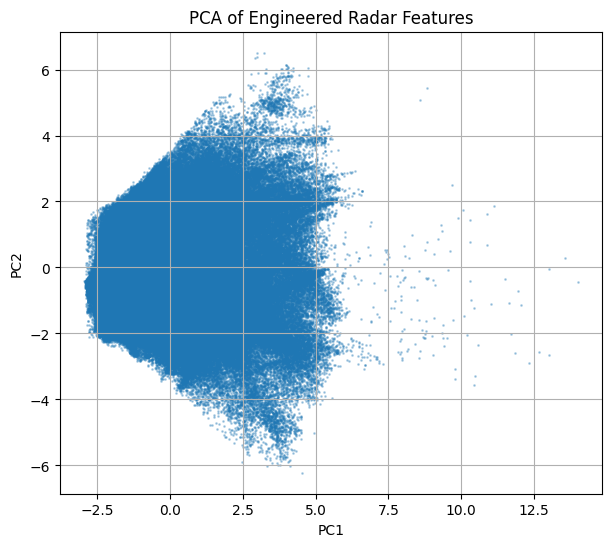

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["x","y","distance","vr","power_norm","speed_abs","angle_deg"]

X = df_eng[features].values
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=1, alpha=0.3)
plt.title("PCA of Engineered Radar Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


This PCA plot shows how all the engineered radar features compress into two main directions of variation, revealing the overall structure of the dataset. Most of the variance lies along PC1, meaning features like range, distance, and x–y position dominate the behavior of the radar points, while PC2 captures smaller effects such as azimuth or RCS differences. The “fan-shaped” spread matches the physical geometry of automotive radar, confirming that the feature engineering is working correctly. Because the points form one large overlapping cloud rather than distinct clusters, the plot also indicates that object classes are not easily separable using simple features—so more advanced modeling will be needed later.

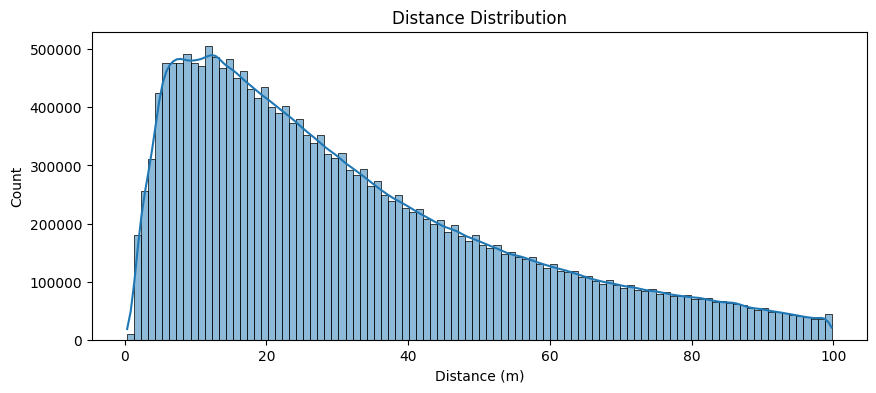

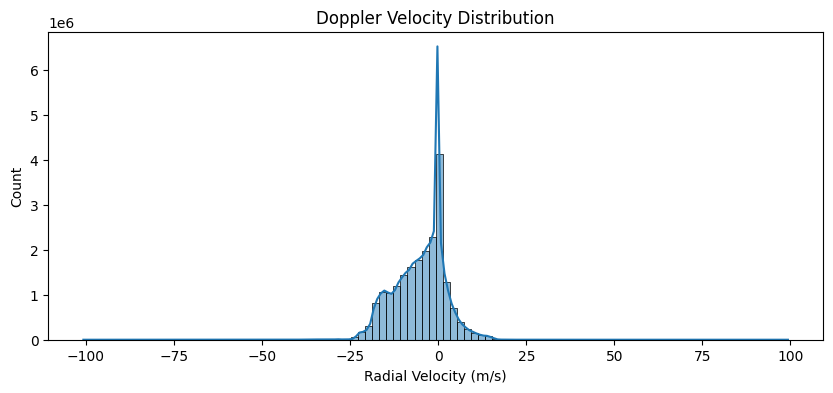

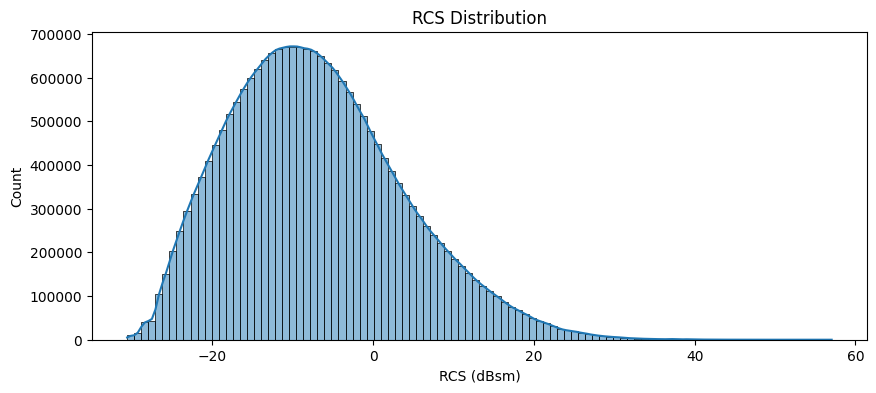

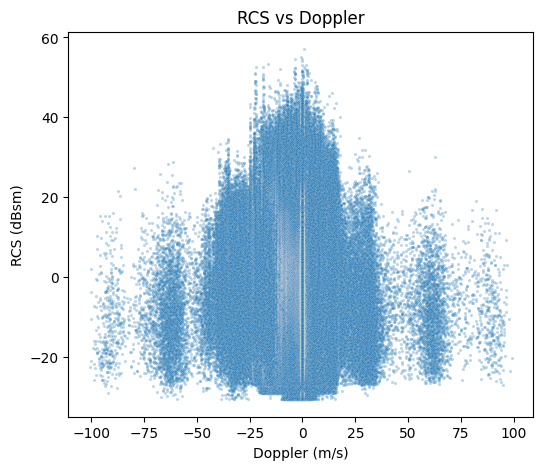

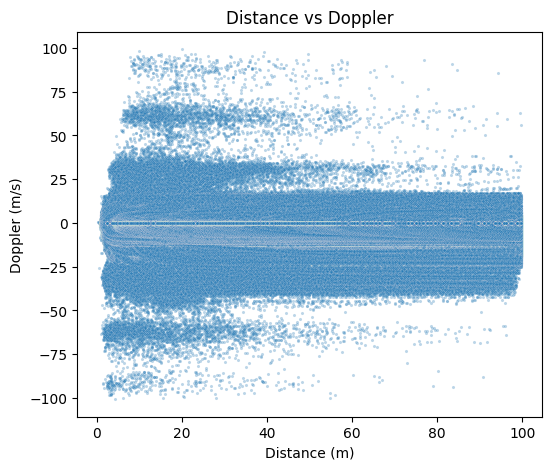

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_parquet("/home/rraricha/RadarScenes-ml-project/data/engineered_features.parquet")

# 1) Distance Histogram
plt.figure(figsize=(10,4))
sns.histplot(df["distance"], bins=100, kde=True)
plt.title("Distance Distribution")
plt.xlabel("Distance (m)")
plt.show()

# 2) Doppler Histogram
plt.figure(figsize=(10,4))
sns.histplot(df["vr"], bins=100, kde=True)
plt.title("Doppler Velocity Distribution")
plt.xlabel("Radial Velocity (m/s)")
plt.show()

# 3) RCS Histogram
plt.figure(figsize=(10,4))
sns.histplot(df["rcs"], bins=100, kde=True)
plt.title("RCS Distribution")
plt.xlabel("RCS (dBsm)")
plt.show()

# 4) RCS vs Doppler
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["vr"], y=df["rcs"], s=5, alpha=0.3)
plt.title("RCS vs Doppler")
plt.xlabel("Doppler (m/s)")
plt.ylabel("RCS (dBsm)")
plt.show()

# 5) Distance vs Doppler
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["distance"], y=df["vr"], s=5, alpha=0.3)
plt.title("Distance vs Doppler")
plt.xlabel("Distance (m)")
plt.ylabel("Doppler (m/s)")
plt.show()


/tmp/ipykernel_1298649/392731525.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(SAMPLES_PER_CLASS, len(x)), random_state=42))


Original size: 20922236
Sampled size: 47436


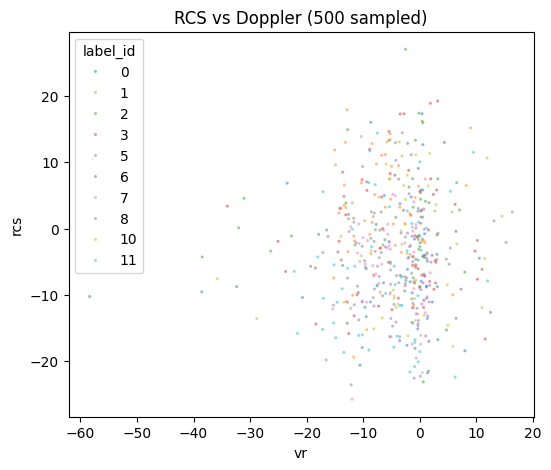

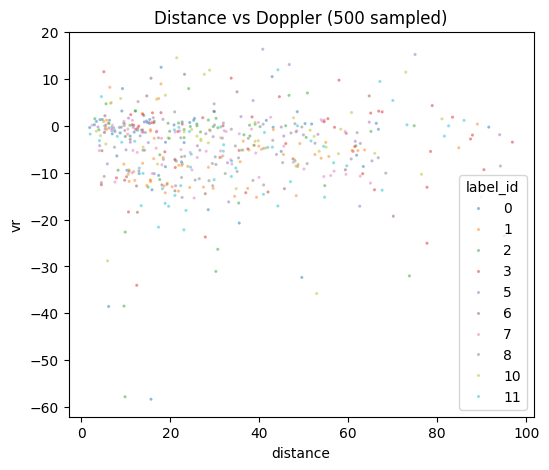

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load engineered dataset
df = pd.read_parquet("../data/engineered_features.parquet")

# ---- Stratified sampling ----
# sample 12,000 from each class (or fewer if class is small)
SAMPLES_PER_CLASS = 5000

df_sampled = (
    df.groupby("label_id")
      .apply(lambda x: x.sample(min(SAMPLES_PER_CLASS, len(x)), random_state=42))
      .reset_index(drop=True)
)

print("Original size:", len(df))
print("Sampled size:", len(df_sampled))

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df_sampled.sample(500, random_state=42),
    x='vr',
    y='rcs',
    hue='label_id',
    s=5,
    palette='tab10',
    alpha=0.5
)
plt.title("RCS vs Doppler (500 sampled)")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df_sampled.sample(500, random_state=42),
    x='distance',
    y='vr',
    hue='label_id',
    s=5,
    palette='tab10',
    alpha=0.5
)
plt.title("Distance vs Doppler (500 sampled)")
plt.show()


/tmp/ipykernel_1298649/2361451722.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df2.groupby("label_id").apply(lambda x: x.sample(10, random_state=42)).reset_index(drop=True)


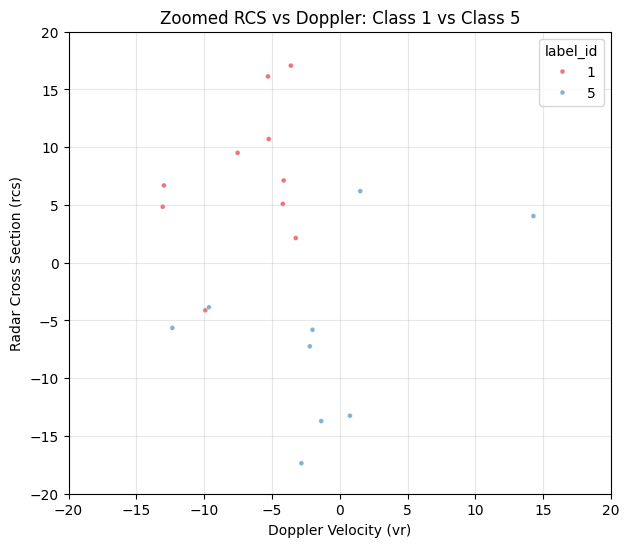

In [ ]:
CLASS_A = 1   # car
CLASS_B = 5   # pedestrian
df2 = df_sampled[df_sampled["label_id"].isin([CLASS_A, CLASS_B])]

# Sample fewer points for visibility
df2 = df2.groupby("label_id").apply(lambda x: x.sample(10, random_state=42)).reset_index(drop=True)

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df2,
    x="vr",
    y="rcs",
    hue="label_id",
    s=12,
    alpha=0.6,
    palette="Set1"
)

plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.xlabel("Doppler Velocity (vr)")
plt.ylabel("Radar Cross Section (rcs)")
plt.title(f"Zoomed RCS vs Doppler: Class {CLASS_A} vs Class {CLASS_B}")
    
plt.grid(True, alpha=0.3)

plt.show()
